# Decision Trees Model for Amazon Reviews Sentiment Analysis

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

## Step 1: Data Loading and Exploration

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
# Load the balanced dataset
path = "/content/drive/MyDrive/data/raw/train.csv"
column_names = ['target', 'title_review', 'content_review']
df = pd.read_csv(path, header=None, names=column_names, dtype=str, nrows=80000)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape: (80000, 3)

First few rows:
  target                                       title_review  \
0      2                     Stuning even for the non-gamer   
1      2              The best soundtrack ever to anything.   
2      2                                           Amazing!   
3      2                               Excellent Soundtrack   
4      2  Remember, Pull Your Jaw Off The Floor After He...   

                                      content_review  
0  This sound track was beautiful! It paints the ...  
1  I'm reading a lot of reviews saying that this ...  
2  This soundtrack is my favorite music of all ti...  
3  I truly like this soundtrack and I enjoy video...  
4  If you've played the game, you know how divine...  

Data types:
target            object
title_review      object
content_review    object
dtype: object

Missing values:
target            0
title_review      5
content_review    0
dtype: int64


## Step 2: Text Preprocessing Function

In [41]:
def preprocess_text(text):
    """
    Preprocess text: lowercase, remove special characters, remove stopwords, tokenize
    """
    # Convert to lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenization and stopword removal
    stop_words = set(stopwords.words('english'))
    try:
        tokens = word_tokenize(text)
        tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
        text = ' '.join(tokens)
    except:
        pass
    return text
# Test preprocessing
print("Testing preprocessing:")
sample_text = df['content_review'].iloc[0]
print(f"Original: {sample_text[:100]}")
print(f"Preprocessed: {preprocess_text(sample_text)[:100]}")

Testing preprocessing:
Original: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even t
Preprocessed: this sound track was beautiful it paints the senery in your mind so well i would recomend it even to


## Step 3: Apply Preprocessing to Dataset

In [42]:
# Combine title and content for better features
df['combined_text'] = df['title_review'].fillna('') + ' ' + df['content_review'].fillna('')
# Apply preprocessing
print("Preprocessing text data...")
df['processed_text'] = df['combined_text'].apply(preprocess_text)
# Remove empty rows after preprocessing
df = df[df['processed_text'].str.len() > 0].reset_index(drop=True)
print(f"Dataset shape after preprocessing: {df.shape}")
# Convert target to numeric
df['target'] = df['target'].astype(int)
print(f"\nClass distribution:\n{df['target'].value_counts()}")

Preprocessing text data...
Dataset shape after preprocessing: (80000, 5)

Class distribution:
target
2    41015
1    38985
Name: count, dtype: int64


## Step 4: Feature Engineering - TF-IDF Vectorization

In [43]:
# Split data first (before vectorization to avoid data leakage)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['processed_text'],
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)
print(f"Training set size: {len(X_train_text)}")
print(f"Test set size: {len(X_test_text)}")
# TF-IDF Vectorization
print("\nFitting TF-IDF Vectorizer...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    sublinear_tf=True,
    strip_accents='unicode'
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
print(f"TF-IDF feature shape: {X_train_tfidf.shape}")
print(f"Number of features extracted: {len(tfidf_vectorizer.get_feature_names_out())}")

Training set size: 64000
Test set size: 16000

Fitting TF-IDF Vectorizer...
TF-IDF feature shape: (64000, 5000)
Number of features extracted: 5000


## Step 5: Decision Tree Model Training

In [44]:
# Train Decision Tree Classifier
print("Training Decision Tree Classifier...")
start_time = time.time()
dt_classifier = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
)
dt_classifier.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.4f} seconds")

Training Decision Tree Classifier...
Training completed in 25.0599 seconds


## Step 6: Model Evaluation

In [45]:
# Make predictions
y_pred = dt_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("DECISION TREE CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {training_time:.4f} seconds")

DECISION TREE CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.7418
Precision: 0.7569
Recall:    0.6924
F1-Score:  0.7232
Training Time: 25.0599 seconds


## Step 7: Classification Report

In [46]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.69      0.72      7797
    Positive       0.73      0.79      0.76      8203

    accuracy                           0.74     16000
   macro avg       0.74      0.74      0.74     16000
weighted avg       0.74      0.74      0.74     16000



## Step 8: Confusion Matrix Visualization

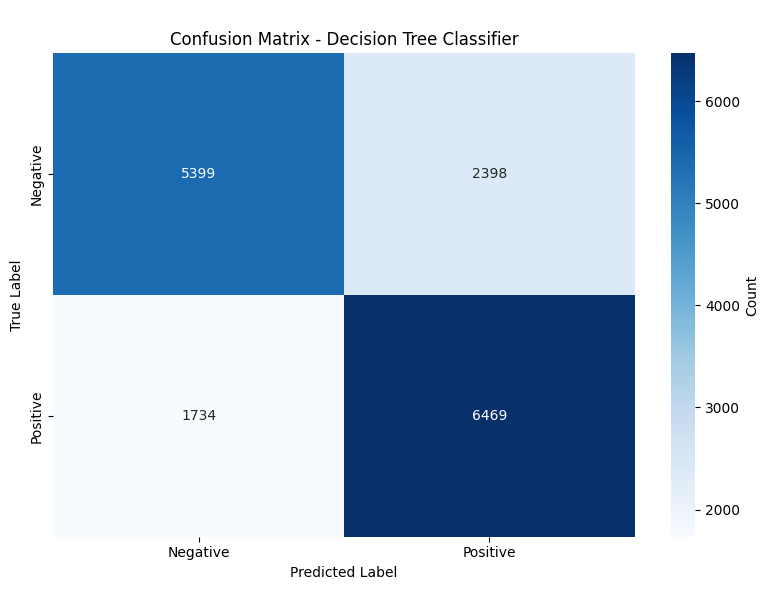

Confusion Matrix:
[[5399 2398]
 [1734 6469]]

True Negatives: 5399
False Positives: 2398
False Negatives: 1734
True Positives: 6469


In [47]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('\nConfusion Matrix - Decision Tree Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('decision_tree_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Step 9: Feature Importance

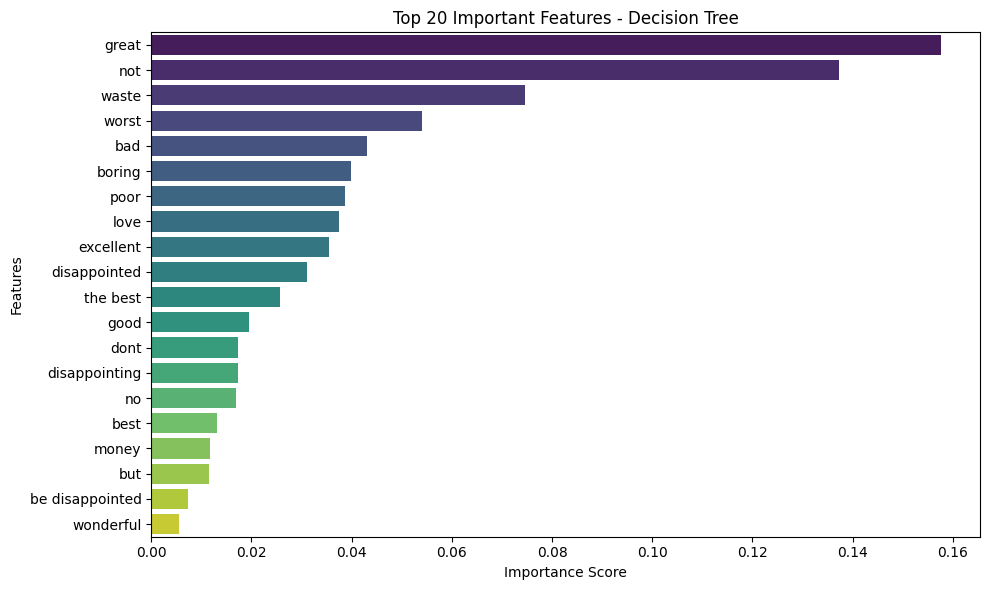


Top 20 Important Features:
        feature  importance
          great    0.157550
            not    0.137285
          waste    0.074627
          worst    0.054135
            bad    0.043134
         boring    0.039924
           poor    0.038675
           love    0.037440
      excellent    0.035434
   disappointed    0.031012
       the best    0.025701
           good    0.019478
           dont    0.017259
  disappointing    0.017257
             no    0.016840
           best    0.013084
          money    0.011724
            but    0.011584
be disappointed    0.007343
      wonderful    0.005580


In [48]:
# Get feature importance
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_importance = dt_classifier.feature_importances_
# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False).head(20)
# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Important Features - Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('decision_tree_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 20 Important Features:")
print(importance_df.to_string(index=False))

## Step 10: Model Summary

In [49]:
print("DECISION TREE MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Max Depth: {dt_classifier.max_depth}")
print(f"  - Min Samples Split: {dt_classifier.min_samples_split}")
print(f"  - Min Samples Leaf: {dt_classifier.min_samples_leaf}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {training_time:.4f} seconds")

DECISION TREE MODEL SUMMARY

Model Parameters:
  - Max Depth: 15
  - Min Samples Split: 10
  - Min Samples Leaf: 5

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.7418
  - Precision: 0.7569
  - Recall:    0.6924
  - F1-Score:  0.7232
  - Training Time: 25.0599 seconds
